# Développement d’un score d’appétence pour la souscription à un produit bancaire via régression logistique

## Presentation du projet

Dans le cadre de ce projet, je m’intéresse à une problématique de marketing bancaire, centrée sur l’optimisation des campagnes de prospection client.

Pour cela, j’exploite une base de données issue d’une campagne d’enquête téléphonique menée par une banque portugaise, dont l’objectif était d’identifier les clients susceptibles de souscrire à un dépôt à terme.

Ce type de problématique est crucial pour les institutions financières, car il permet d’améliorer l’efficacité des campagnes marketing tout en réduisant les coûts liés aux sollicitations inutiles.

## Objectif du projet

L’objectif principal de ce projet est de prédire la probabilité qu’un client souscrive à un dépôt à terme, à partir de ses caractéristiques socio-économiques et des informations issues des campagnes marketing.

Pour répondre à cet objectif, j’ai mis en place un modèle de régression logistique, adapté aux problèmes de classification binaire.

La variable cible, notée response_Binary, représente la décision du client :

1 : le client souscrit au dépôt à terme
0 : le client ne souscrit pas

Ce travail permet ainsi de construire un modèle prédictif capable d’aider la banque à :

mieux cibler ses clients
améliorer le taux de conversion des campagnes
optimiser l’allocation de ses ressources marketing

## Importation des packages

In [44]:
# Importer les modules nécessaires
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## Chargement des données

In [45]:
bankdata=pd.read_csv("bank_cleaned.csv",sep=",",index_col=0)

In [46]:
bankdata.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,response,response_binary
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no,0
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no,0


### Affichage du resumé statistique de la base donnée

In [89]:
bankdata.describe(include='all')

,age,profession,situation_familiale,niveau_etudes,defaut_credit,solde_bancaire,pret_immobilier,pret_personnel,jour_du_mois,mois,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,resultat_campagne_precedente,reponse_campagne_actuelle,reponse_campagne_actuelle_binaire
count,40841.000000,40841,40841,40841,40841,40841.000000,40841,40841,40841.000000,40841,40841.000000,40841.000000,40841.000000,40841.000000,40841,40841,40841.000000
unique,NaN,12,3,3,2,NaN,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2,NaN
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,NaN,may,NaN,NaN,NaN,NaN,unknown,no,NaN
freq,NaN,8805,24641,21933,40078,NaN,22820,34042,NaN,12496,NaN,NaN,NaN,NaN,34802,36202,NaN
mean,40.790676,NaN,NaN,NaN,NaN,1073.981807,NaN,NaN,15.863666,NaN,4.308949,2.774149,32.248304,0.436791,NaN,NaN,0.113587
std,10.475473,NaN,NaN,NaN,NaN,1712.556186,NaN,NaN,8.313608,NaN,4.305823,3.104177,90.738402,1.572342,NaN,NaN,0.317313
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,1.000000,NaN,0.100000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,64.000000,NaN,NaN,8.000000,NaN,1.730000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,421.000000,NaN,NaN,16.000000,NaN,3.000000,2.000000,-1.000000,0.000000,NaN,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1333.000000,NaN,NaN,21.000000,NaN,5.300000,3.000000,-1.000000,0.000000,NaN,NaN,0.000000


## Description de la base de données "bank_cleaned.csv"

La base de données "bank_cleaned.csv" contient des données sur les campagnes de marketing direct (appels téléphoniques) d'une institution bancaire portugaise. Les données ont été nettoyées et préparées pour l'analyse.

Les caractéristiques (variables explicatives) enregistrées pour chaque client sont les suivantes :

age : l'âge du client (variable numérique)

job : la profession du client (variable catégorielle)

marital : l'état matrimonial du client (variable catégorielle)

education : le niveau d'éducation du client (variable catégorielle)

default : indique si le client a un crédit en défaut ou non (variable catégorielle)

balance : le solde du compte du client (variable numérique)

housing : indique si le client a un prêt immobilier ou non (variable catégorielle)

loan : indique si le client a un prêt personnel ou non (variable catégorielle)

day : le jour du mois de la dernière communication avec le client (variable numérique)

month : le mois de la dernière communication avec le client (variable catégorielle)

duration : la durée de la dernière communication avec le client, en secondes (variable numérique)

campaign : le nombre de contacts effectués au cours de cette campagne pour ce client (variable numérique)

pdays : le nombre de jours écoulés depuis le dernier contact avec le client lors d'une campagne précédente (variable numérique ; 999 signifie que le client n'a pas été contacté précédemment)

previous : le nombre de contacts effectués avant cette campagne pour ce client (variable numérique)

poutcome : le résultat de la précédente campagne marketing (variable catégorielle)

response : la réponse du client à la dernière campagne marketing (variable catégorielle)

response_binary : la réponse du client à la dernière campagne marketing, encodée en binaire (0 = pas intéressé, 1 = intéressé) (variable numérique)

La variable cible est :

    response_binary : a-t-il souscrit un dépôt à terme ? (variable catégorielle)

Les données ont été préparées pour l'analyse en remplaçant les valeurs manquantes par des valeurs médianes ou moyennes, en convertissant les variables catégorielles en variables binaires, et en supprimant les variables inutiles ou redondantes.

La base de données contient 4521 entrées (lignes) et 9 caractéristiques (colonnes).

In [47]:
# Renommer les colonnes
bankdata.rename(columns={
    'age': 'age',
    'job': 'profession',
    'marital': 'situation_familiale',
    'education': 'niveau_etudes',
    'default': 'defaut_credit',
    'balance': 'solde_bancaire',
    'housing': 'pret_immobilier',
    'loan': 'pret_personnel',
    'day': 'jour_du_mois',
    'month': 'mois',
    'duration': 'duree_appel',
    'campaign': 'nb_appels',
    'pdays': 'nb_jours_depuis_dernier_appel',
    'previous': 'nb_appels_precedents',
    'poutcome': 'resultat_campagne_precedente',
    'response': 'reponse_campagne_actuelle',
    'response_binary': 'reponse_campagne_actuelle_binaire'
}, inplace=True)

# Afficher les noms de colonnes mis à jour
print(bankdata.columns)


Index(['age', 'profession', 'situation_familiale', 'niveau_etudes',
       'defaut_credit', 'solde_bancaire', 'pret_immobilier', 'pret_personnel',
       'jour_du_mois', 'mois', 'duree_appel', 'nb_appels',
       'nb_jours_depuis_dernier_appel', 'nb_appels_precedents',
       'resultat_campagne_precedente', 'reponse_campagne_actuelle',
       'reponse_campagne_actuelle_binaire'],
      dtype='object')


## Qualité des données

In [48]:
bankdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40841 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                40841 non-null  int64  
 1   profession                         40841 non-null  object 
 2   situation_familiale                40841 non-null  object 
 3   niveau_etudes                      40841 non-null  object 
 4   defaut_credit                      40841 non-null  object 
 5   solde_bancaire                     40841 non-null  int64  
 6   pret_immobilier                    40841 non-null  object 
 7   pret_personnel                     40841 non-null  object 
 8   jour_du_mois                       40841 non-null  int64  
 9   mois                               40841 non-null  object 
 10  duree_appel                        40841 non-null  float64
 11  nb_appels                          40841 non-null  int64  


In [49]:
bankdata.describe(include="all")

,age,profession,situation_familiale,niveau_etudes,defaut_credit,solde_bancaire,pret_immobilier,pret_personnel,jour_du_mois,mois,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,resultat_campagne_precedente,reponse_campagne_actuelle,reponse_campagne_actuelle_binaire
count,40841.000000,40841,40841,40841,40841,40841.000000,40841,40841,40841.000000,40841,40841.000000,40841.000000,40841.000000,40841.000000,40841,40841,40841.000000
unique,NaN,12,3,3,2,NaN,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2,NaN
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,NaN,may,NaN,NaN,NaN,NaN,unknown,no,NaN
freq,NaN,8805,24641,21933,40078,NaN,22820,34042,NaN,12496,NaN,NaN,NaN,NaN,34802,36202,NaN
mean,40.790676,NaN,NaN,NaN,NaN,1073.981807,NaN,NaN,15.863666,NaN,4.308949,2.774149,32.248304,0.436791,NaN,NaN,0.113587
std,10.475473,NaN,NaN,NaN,NaN,1712.556186,NaN,NaN,8.313608,NaN,4.305823,3.104177,90.738402,1.572342,NaN,NaN,0.317313
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,1.000000,NaN,0.100000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,64.000000,NaN,NaN,8.000000,NaN,1.730000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,421.000000,NaN,NaN,16.000000,NaN,3.000000,2.000000,-1.000000,0.000000,NaN,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1333.000000,NaN,NaN,21.000000,NaN,5.300000,3.000000,-1.000000,0.000000,NaN,NaN,0.000000


In [50]:
bankdata.isnull().sum()

,0
age,0
profession,0
situation_familiale,0
niveau_etudes,0
defaut_credit,0
solde_bancaire,0
pret_immobilier,0
pret_personnel,0
jour_du_mois,0
mois,0


Après une analyse approfondie de la qualité des données, il ressort que la base ne présente aucune valeur manquante.

Cette complétude des données constitue un atout, car elle permet d’appliquer directement les méthodes de modélisation sans recourir à des techniques d’imputation, garantissant ainsi une meilleure fiabilité des résultats.

## Descripition de la base de données

In [51]:
# Créer une nouvelle version de la base de données sans la variable "response"
bankdata_new = bankdata.drop(columns=['reponse_campagne_actuelle_binaire'])
bankdata_new.head()

,age,profession,situation_familiale,niveau_etudes,defaut_credit,solde_bancaire,pret_immobilier,pret_personnel,jour_du_mois,mois,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,resultat_campagne_precedente,reponse_campagne_actuelle
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no


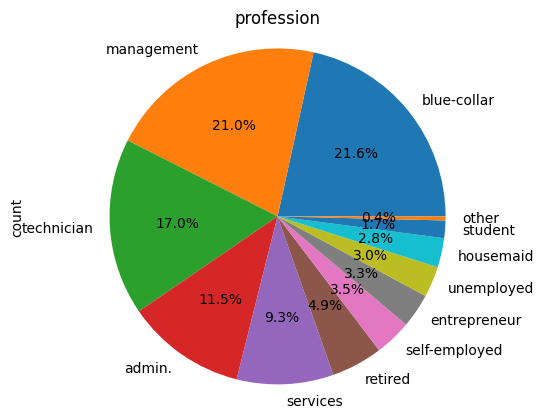

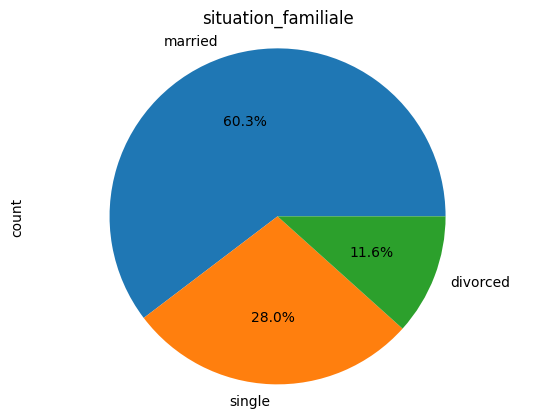

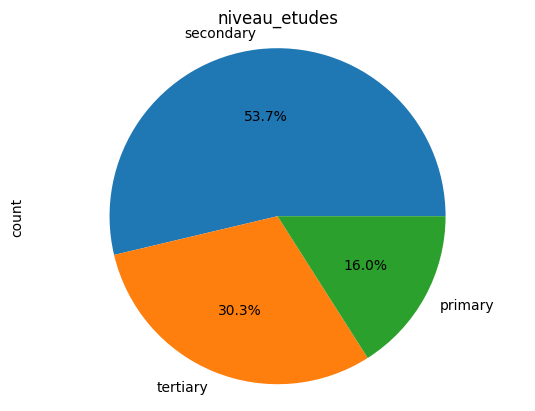

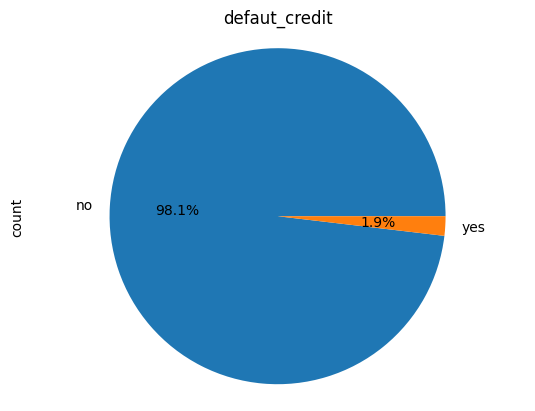

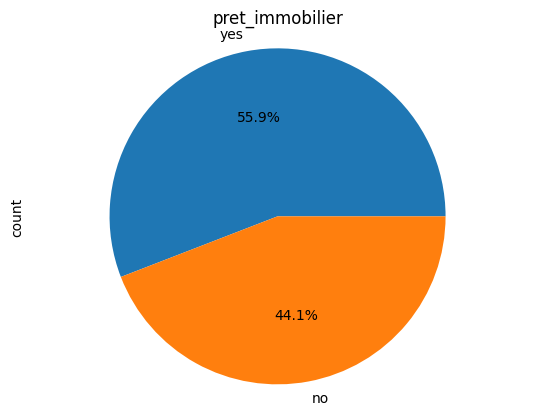

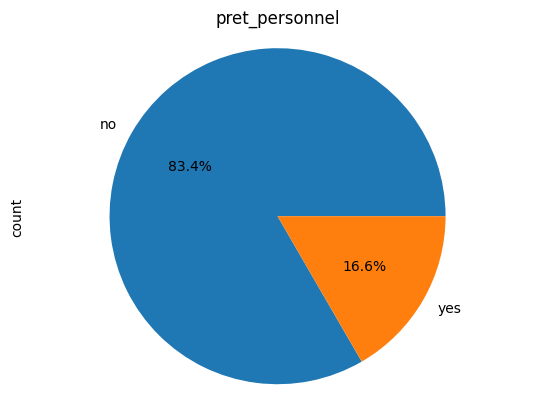

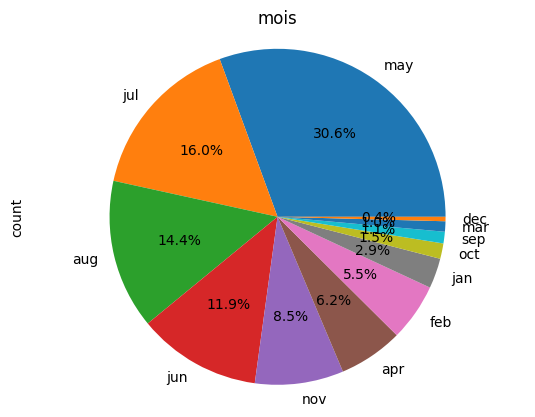

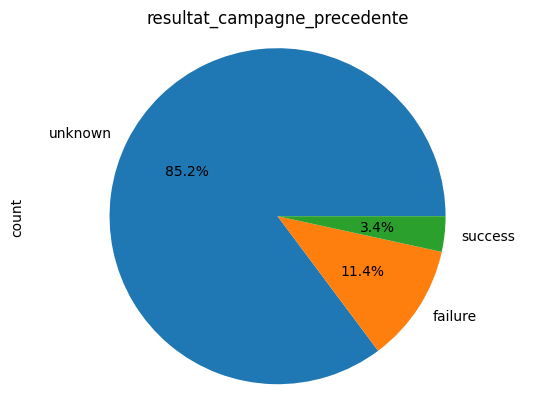

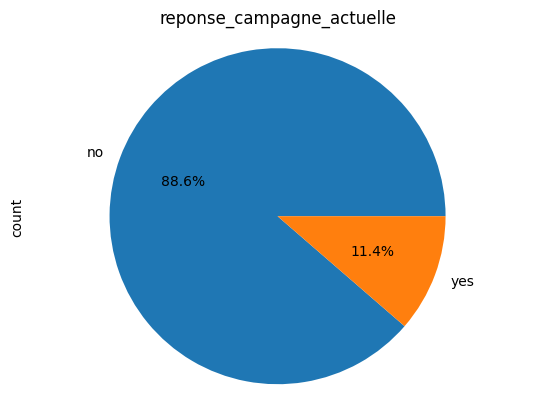

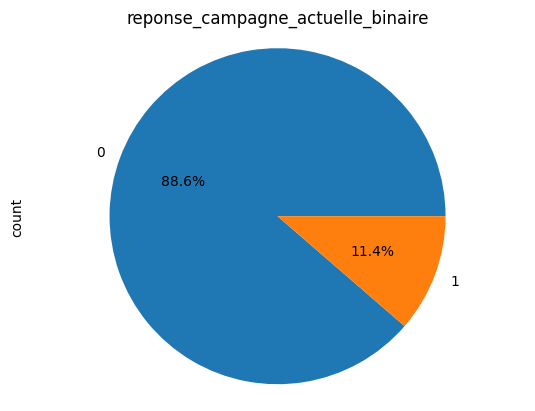

In [52]:
# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel',
             'mois', 'resultat_campagne_precedente', 'reponse_campagne_actuelle', 'reponse_campagne_actuelle_binaire']


# Générer un pie plot pour chaque variable catégorielle
for var in cat_vars:
    bankdata[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)
    plt.axis('equal')
    plt.show()


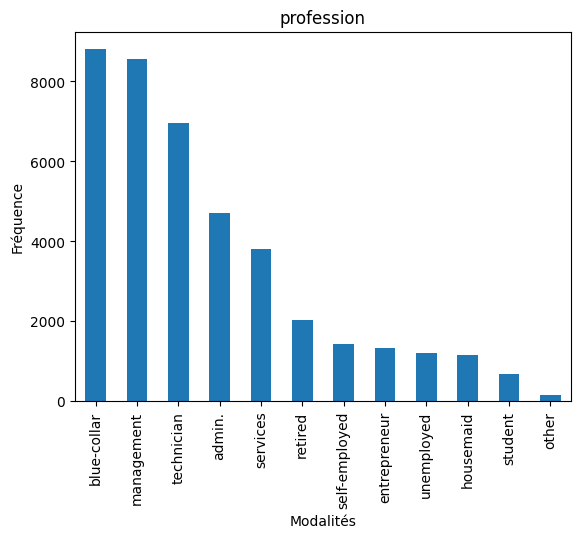

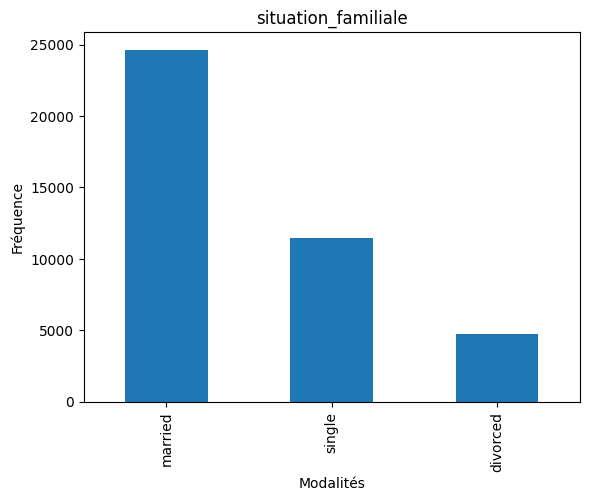

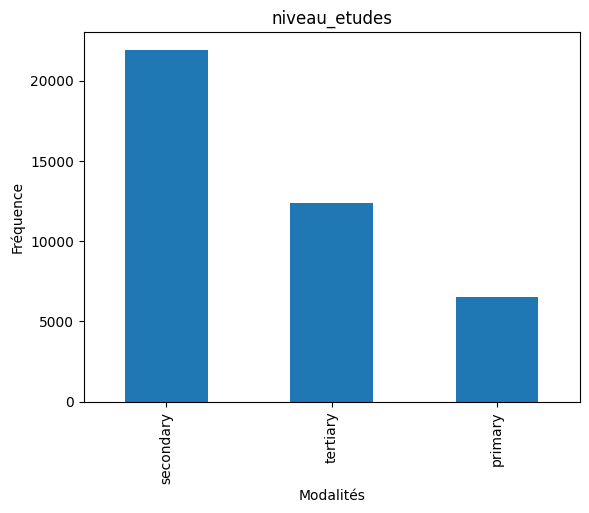

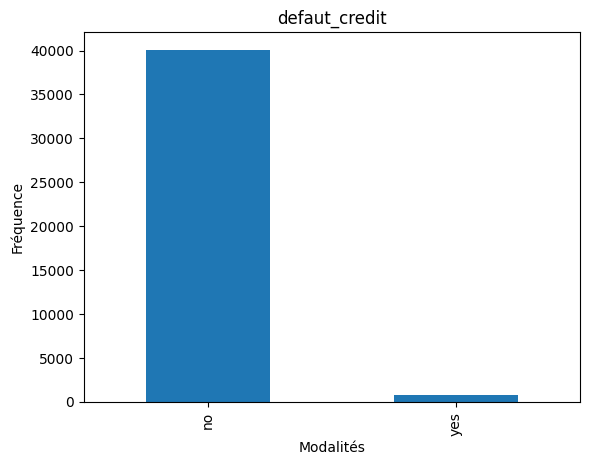

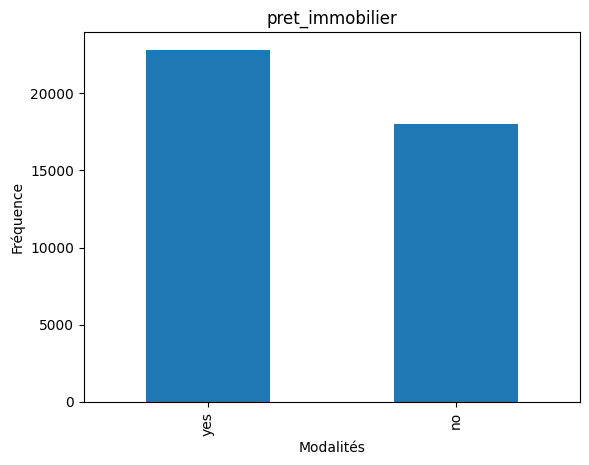

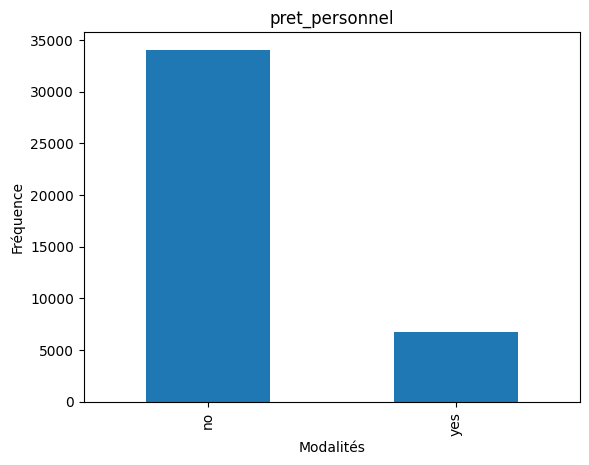

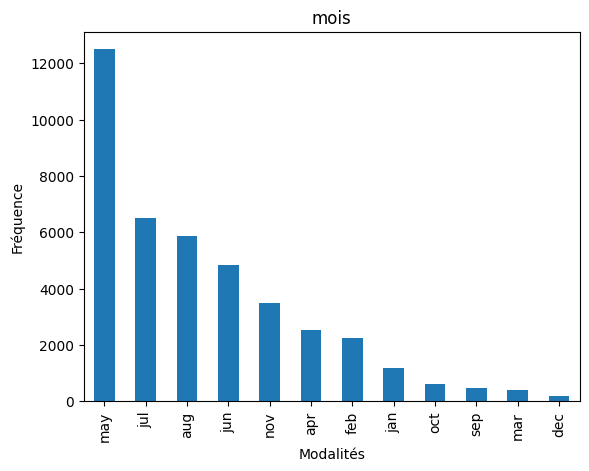

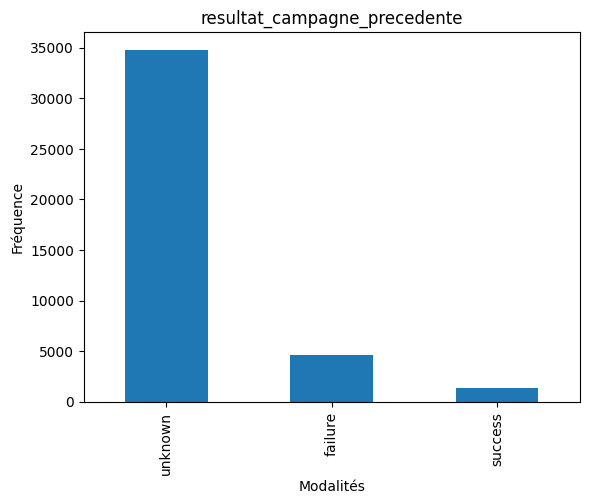

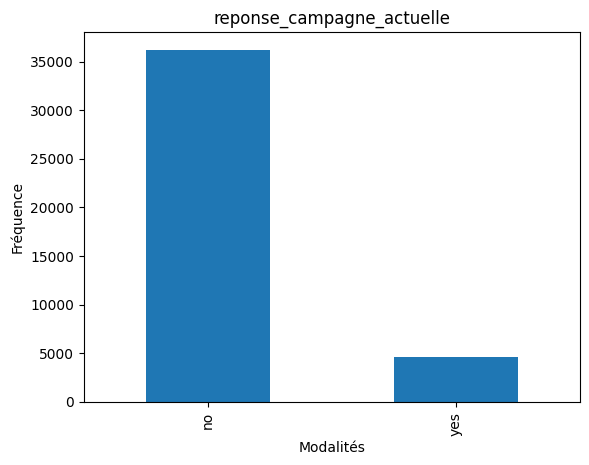

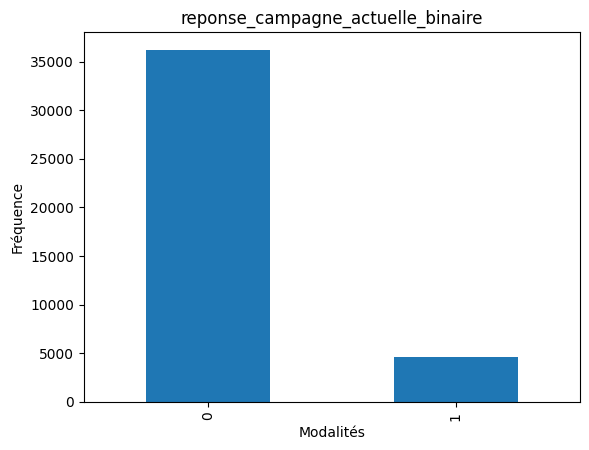

In [53]:
# Générer un bar plot pour chaque variable catégorielle
for var in cat_vars:
    bankdata[var].value_counts().plot(kind='bar')
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Fréquence')
    plt.show()


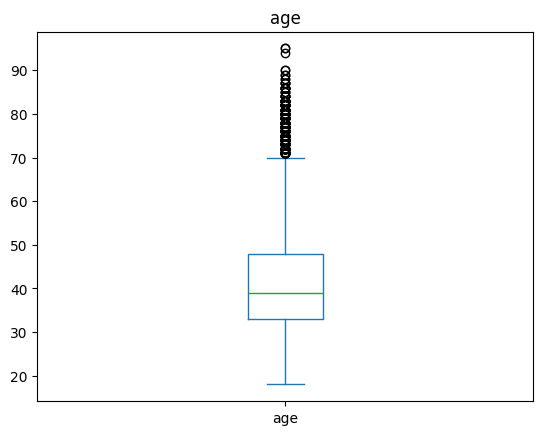

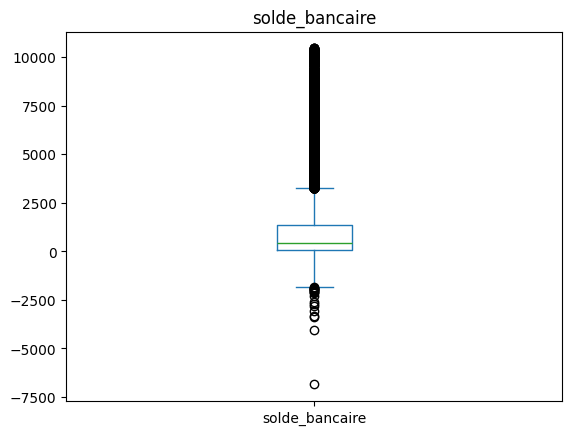

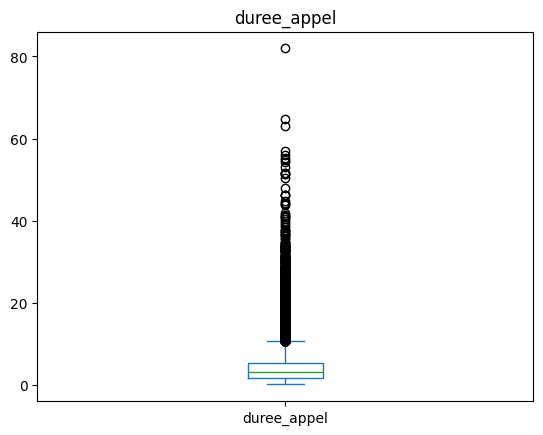

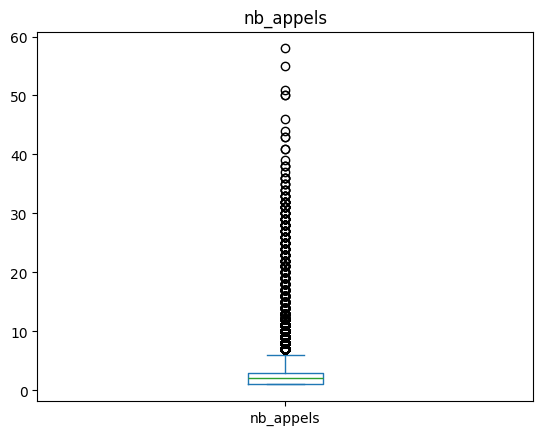

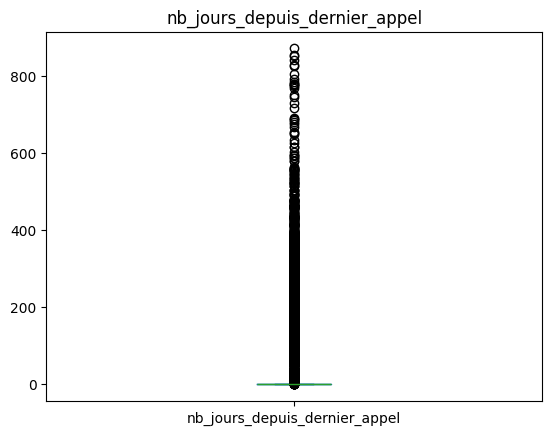

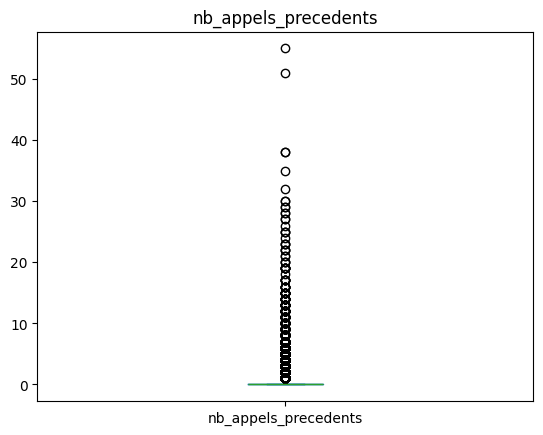

In [54]:
# Sélectionner les variables numériques
num_vars = ['age', 'solde_bancaire', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel', 'nb_appels_precedents']

# Générer un box plot pour chaque variable numérique
for var in num_vars:
    bankdata[var].plot(kind='box')
    plt.title(var)
    plt.show()


Après avoir visualisé la distribution de ma variable d’intérêt, j’observe un déséquilibre important entre les clients qui souscrivent au dépôt à terme et ceux qui ne souscrivent pas.

Ce déséquilibre peut entraîner des biais dans l’apprentissage du modèle, notamment un risque de surapprentissage en faveur de la classe majoritaire.

Afin de garantir de meilleures performances prédictives, ce problème sera pris en compte et traité dans la partie dédiée à l’amélioration du modèle.

## Analyses bivariée

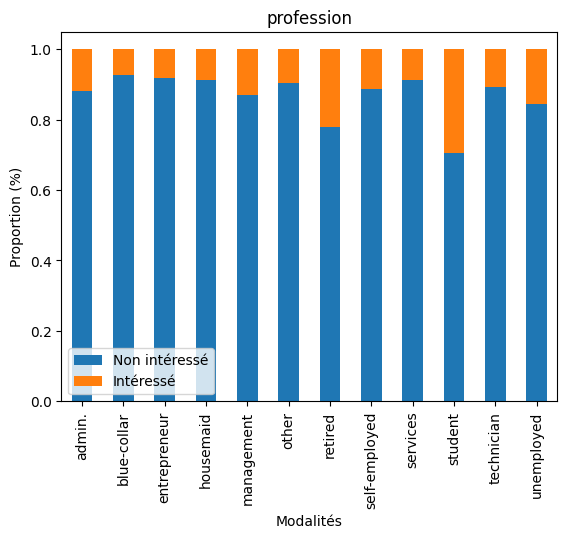

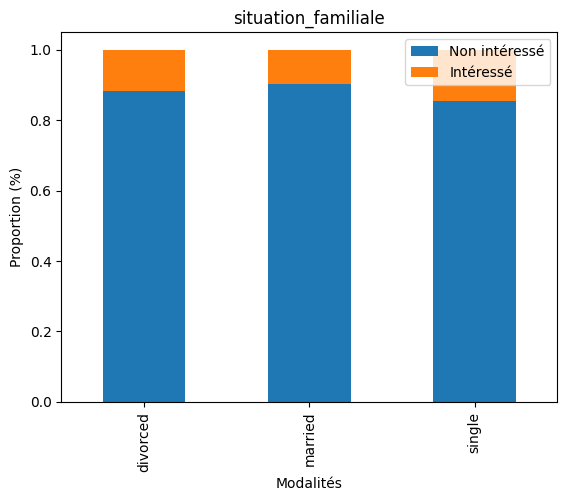

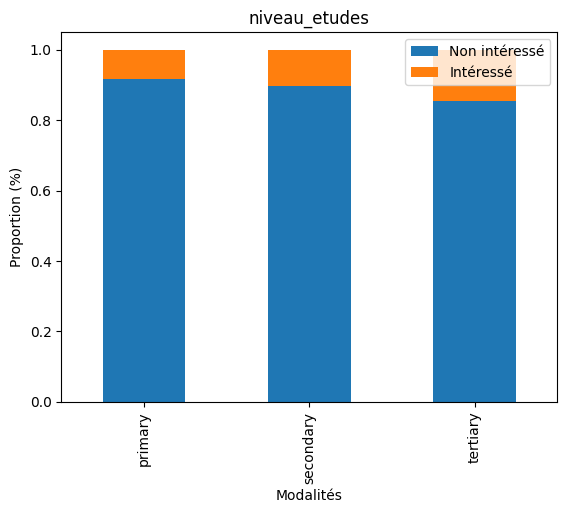

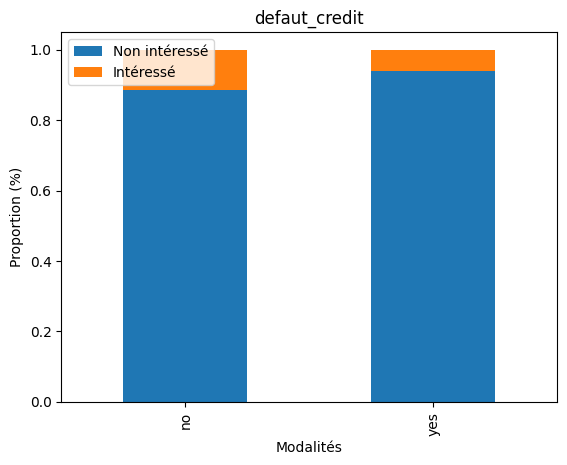

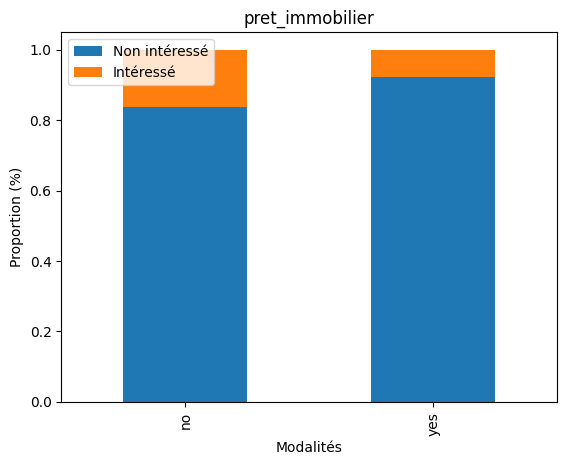

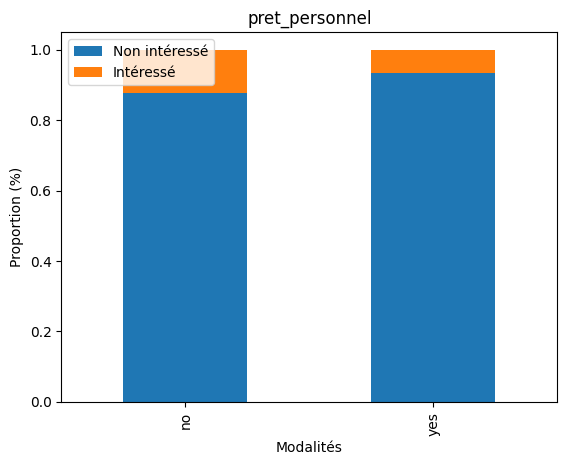

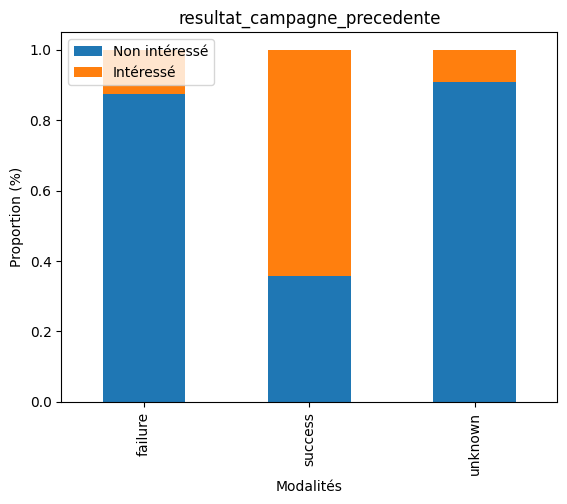

In [55]:
import seaborn as sns
# Sélectionner les variables catégorielles
# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel', 'resultat_campagne_precedente']


# Générer un count plot pour chaque variable catégorielle
# Définir la taille des figures




# Générer un bar plot pour chaque variable catégorielle
for var in cat_vars:
    figsize = (20, 20)
    (bankdata.groupby([var, 'reponse_campagne_actuelle_binaire'])['reponse_campagne_actuelle_binaire'].count()/bankdata.groupby([var])[var].count()).unstack(level=1).plot(kind='bar', stacked=True)
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Proportion (%)')
    plt.legend(['Non intéressé', 'Intéressé'])
    plt.show()

In [56]:
from scipy.stats import chi2_contingency
# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel', 'resultat_campagne_precedente']

# Initialiser les listes pour stocker les résultats
var_names = []
chi2_stats = []
p_values = []
cramer_vs = []

# Parcourir toutes les variables catégorielles
for var in cat_vars:
    # Calculer le tableau de contingence
    contingency_table = pd.crosstab(bankdata['reponse_campagne_actuelle_binaire'], bankdata[var])
    # Calculer la statistique de test du Chi-deux et la p-valeur
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Calculer le coefficient V de Cramer
    n = contingency_table.sum().sum()
    phi2 = chi2/n
    r,k = contingency_table.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rc = r-((r-1)**2)/(n-1)
    kc = k-((k-1)**2)/(n-1)
    cramer_v = np.sqrt(phi2corr/min(rc-1,kc-1))
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    chi2_stats.append(chi2)
    p_values.append(p)
    cramer_vs.append(cramer_v)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Chi2': chi2_stats,
    'P-valeur': p_values,
    'V de Cramer': cramer_vs
})

# Trier le DataFrame par ordre croissant de V de Cramer
results_df.sort_values(by='V de Cramer', inplace=True,ascending=False)

# Afficher le tableau des résultats
print(results_df)


                       Variable         Chi2       P-valeur  V de Cramer
6  resultat_campagne_precedente  4072.108164   0.000000e+00     0.315689
4               pret_immobilier   720.301364  1.151140e-158     0.132713
0                    profession   708.668621  7.474840e-145     0.130702
2                 niveau_etudes   210.723005   1.746147e-46     0.071489
1           situation_familiale   181.858771   3.234965e-40     0.066363
5                pret_personnel   176.976953   2.215667e-40     0.065642
3                 defaut_credit    21.401052   3.725668e-06     0.022350


**Mesure de la relation entre la variable d’intérêt et les variables explicatives**

Afin d’évaluer l’intensité de la relation entre la variable d’intérêt et les variables explicatives, j’ai utilisé le test du khi-deux d’indépendance, complété par le calcul du V de Cramer.

Le test du khi-deux permet de vérifier l’existence d’une dépendance entre les variables, tandis que le V de Cramer mesure l’intensité de cette relation.

Les résultats obtenus montrent que les p-values sont inférieures à 0,05 pour l’ensemble des variables explicatives. Cela signifie que l’on rejette l’hypothèse d’indépendance et qu’il existe donc une relation statistiquement significative entre les variables explicatives et la variable d’intérêt, à savoir la souscription à un dépôt à terme.

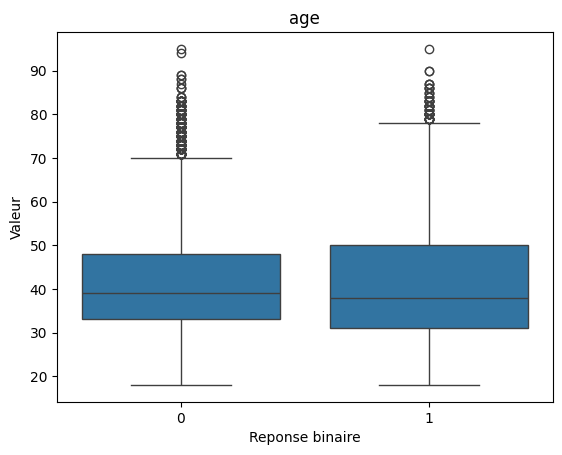

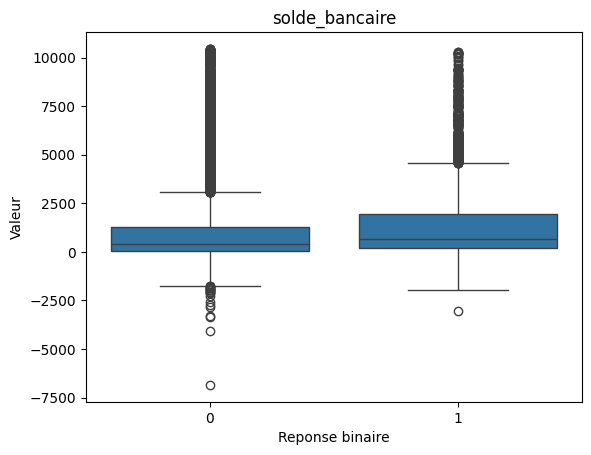

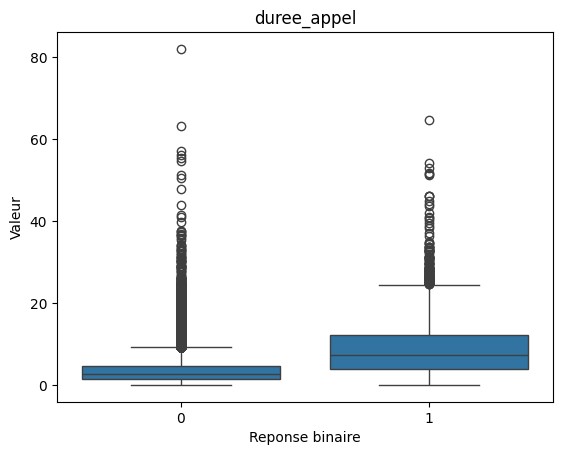

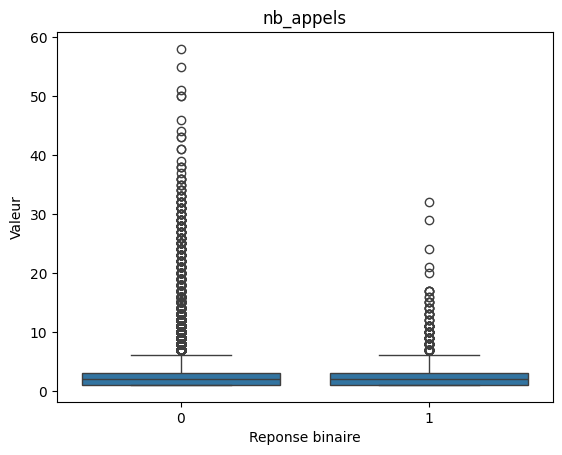

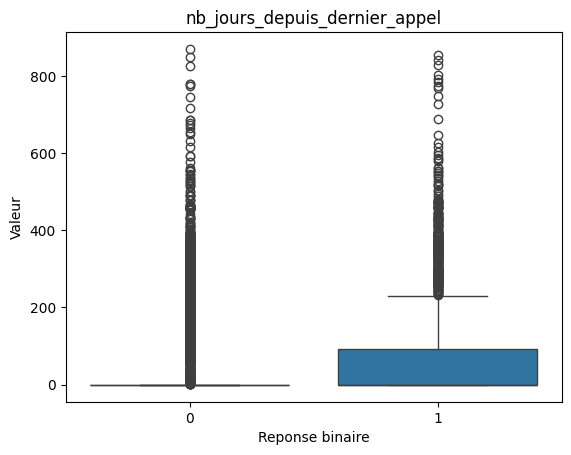

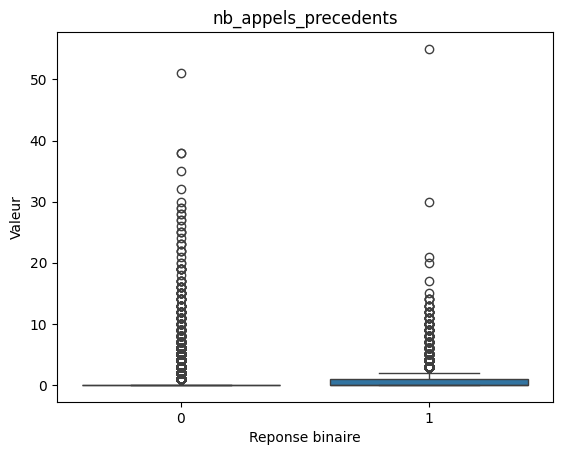

In [57]:
# Sélectionner les variables numériques

# Sélectionner les variables numériques
num_vars = ['age', 'solde_bancaire', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel', 'nb_appels_precedents']


# Générer un box plot pour chaque variable numérique
for var in num_vars:
    sns.boxplot(x='reponse_campagne_actuelle_binaire', y=var, data=bankdata)
    plt.title(var)
    plt.xlabel('Reponse binaire')
    plt.ylabel('Valeur')
    plt.show()


In [58]:
import scipy.stats as stats
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in num_vars:
    # Calculer les groupes de valeurs
    groups = [bankdata[bankdata['reponse_campagne_actuelle_binaire'] == 0][var], bankdata[bankdata['reponse_campagne_actuelle_binaire'] == 1][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)


                        Variable  Kruskal-Wallis       P-valeur
2                    duree_appel     4767.047442   0.000000e+00
5           nb_appels_precedents     1241.504630  5.825212e-272
4  nb_jours_depuis_dernier_appel     1060.285642  1.414875e-232
1                 solde_bancaire      367.404987   6.874073e-82
3                      nb_appels      290.919176   3.135286e-65
0                            age        4.517712   3.354567e-02


## Modélisation

In [59]:
import statsmodels.api as sm
# Sélectionner les variables explicatives et la variable d'intérêt
X = bankdata[['age', 'profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'solde_bancaire',
              'pret_immobilier', 'pret_personnel', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel',
              'nb_appels_precedents', 'resultat_campagne_precedente', 'mois']]
y = bankdata['reponse_campagne_actuelle_binaire']

**Intégration des variables qualitatives**

Pour intégrer les variables qualitatives dans un modèle de régression, il est nécessaire de les transformer en variables numériques. Dans ce projet, j’ai choisi d’utiliser la méthode des variables indicatrices (ou variables dummies).

Cette transformation consiste à représenter chaque modalité d’une variable qualitative par une variable binaire (0 ou 1).

Toutefois, afin d’éviter un problème de multicolinéarité parfaite (appelé aussi piège des variables fictives), il est indispensable de supprimer une des modalités de référence pour chaque variable qualitative.

La modalité supprimée sert alors de catégorie de référence et son effet est implicitement capturé par la constante du modèle, ce qui permet une interprétation correcte des coefficients estimés.

In [60]:
# Convertir les variables catégorielles en variables indicatrices (dummies)
X = pd.get_dummies(X, columns=['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier',
                               'pret_personnel', 'mois', 'resultat_campagne_precedente'], drop_first=True)

# Convertir explicitement les colonnes booléennes en entiers
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

In [61]:
# Ajouter une constante pour l'interception
X = sm.add_constant(X)

In [62]:
# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
print(X_train.dtypes)

const                                   float64
age                                       int64
solde_bancaire                            int64
duree_appel                             float64
nb_appels                                 int64
nb_jours_depuis_dernier_appel             int64
nb_appels_precedents                      int64
profession_blue-collar                    int64
profession_entrepreneur                   int64
profession_housemaid                      int64
profession_management                     int64
profession_other                          int64
profession_retired                        int64
profession_self-employed                  int64
profession_services                       int64
profession_student                        int64
profession_technician                     int64
profession_unemployed                     int64
situation_familiale_married               int64
situation_familiale_single                int64
niveau_etudes_secondary                 

In [64]:
# Créer le modèle de régression logistique
logit_model = sm.Logit(y_train, X_train)


In [65]:
# Ajuster le modèle aux données d'apprentissage
result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.234362
         Iterations 8


Après l’étape de modélisation, une question essentielle se pose : le modèle est-il statistiquement significatif ?

Autrement dit, il s’agit de vérifier s’il existe au moins une variable explicative dont le coefficient est significativement différent de zéro.

Si c’est le cas, cela signifie que le modèle possède un pouvoir explicatif, c’est-à-dire que certaines variables sélectionnées contribuent effectivement à expliquer le phénomène étudié, à savoir la souscription à un dépôt à terme.

Ainsi, la significativité du modèle indique que les variables retenues sont pertinentes pour expliquer la variable d’intérêt.

In [66]:
# Afficher le résumé des résultats de la régression
print(result.summary())

                                   Logit Regression Results                                  
Dep. Variable:     reponse_campagne_actuelle_binaire   No. Observations:                32672
Model:                                         Logit   Df Residuals:                    32634
Method:                                          MLE   Df Model:                           37
Date:                               Sat, 18 Apr 2026   Pseudo R-squ.:                  0.3289
Time:                                       09:31:00   Log-Likelihood:                -7657.1
converged:                                      True   LL-Null:                       -11409.
Covariance Type:                           nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 

### Interpretation de la sortie du modèle

Dans le cas de la régression logistique, on cherche à estimer un modèle qui maximise la vraisemblance.
Autrement dit, on choisit les paramètres qui rendent les observations les plus probables compte tenu du modèle.
Contrairement à la régression linéaire, le coefficient de détermination R
2
 n’est pas une mesure centrale en régression logistique.
On utilise plutôt des indicateurs adaptés comme le pseudo-R
2
, la log-vraisemblance, ou encore des métriques de performance telles que l’AUC, la précision ou le recall.

**Qualité globale du modèle**

LLR p-value = 0.000

 Le modèle est globalement significatif (au moins une variable explique la souscription).

Pseudo R² = 0.3289

Le modèle a un pouvoir explicatif correct (plutôt bon en logit).

**Variables importantes (significatives)**

On regarde les variables avec p-value < 0.05

Variables qui augmentent la probabilité de souscription
durée_appel (+) → effet très fort (la variable la plus importante)

solde_bancaire (+)

nb_appels_precedents (+)

niveau_etudes (secondary, tertiary) (+)

mois_mar, mois_oct, mois_sep (+)

résultat campagne précédente = succès (+++) → effet très fort

**Variables qui diminuent la probabilité**

nb_appels (-) → trop d’appels = effet négatif

prêt immobilier (-)

prêt personnel (-)

Plusieurs professions (blue-collar, entrepreneur, services, etc.)

Plusieurs mois (jan, mai, juin, juillet, etc.)

**Variables non significatives ❌**

 Elles n’expliquent pas vraiment la souscription :

age

nb_jours_depuis_dernier_appel

default_credit_yes

certaines professions

**Conclusion simple**

Le modèle est bon et exploitable

Les facteurs les plus déterminants sont :

la durée de l’appel

le résultat des campagnes précédentes

le profil du client (études, profession)

le moment de contact (mois)

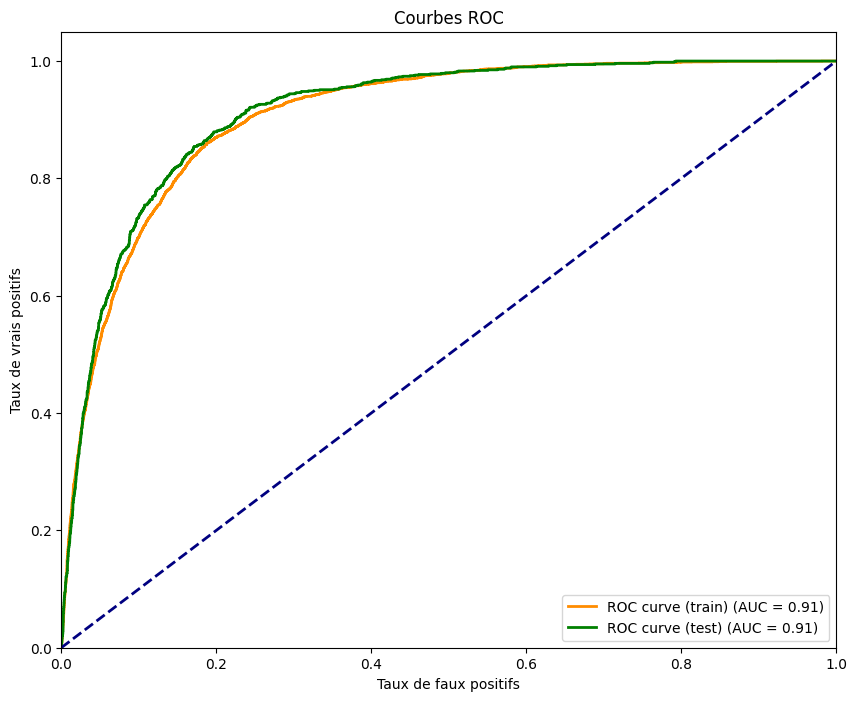

In [67]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
y_train_pred = result.predict(X_train)
y_test_pred = result.predict(X_test)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()


**L’AUC obtenue sur la base d’entraînement et sur la base de test est identique (0,91).**

Cela signifie que le modèle possède une excellente capacité de discrimination : il est capable de distinguer efficacement les clients qui vont souscrire de ceux qui ne vont pas souscrire.

Concrètement, une AUC de 0,91 indique qu’il y a 91 % de chances que le modèle attribue un score plus élevé à un client qui souscrit qu’à un client qui ne souscrit pas.

Par ailleurs, le fait que cette performance soit identique sur les données d’entraînement et de test est un très bon signe : cela suggère que le modèle généralise bien et qu’il n’est pas en situation de surapprentissage (overfitting).

In [68]:
from sklearn.metrics import classification_report

# Prédire les classes sur la base de test
y_pred = result.predict(X_test) > 0.5

# Générer le rapport de classification
report = classification_report(y_test, y_pred)

# Afficher le rapport de classification
print(report)


              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7166
           1       0.67      0.35      0.46      1003

    accuracy                           0.90      8169
   macro avg       0.79      0.66      0.70      8169
weighted avg       0.88      0.90      0.88      8169



**Classe 0 (ne souscrit pas)**

Precision = 0.91

Recall = 0.98

F1-score = 0.94

 Le modèle est excellent pour détecter les clients qui ne souscrivent pas.

 Il en oublie très peu (recall très élevé).

**Classe 1 (souscrit)**

Precision = 0.67

Recall = 0.35

F1-score = 0.46

Le modèle a plus de difficulté sur les clients qui souscrivent :

Il en détecte peu (35%) → beaucoup de faux négatifs
Quand il prédit 1, il a quand même 67 % de chances d’avoir raison

In [69]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[6990  176]
 [ 652  351]]


**Lecture des valeurs**

6990 (Vrais Négatifs - TN)
Clients correctement prédits comme non souscripteurs

176 (Faux Positifs - FP)
Clients prédits comme souscripteurs à tort

652 (Faux Négatifs - FN)
Clients qui auraient souscrit mais que le modèle rate

351 (Vrais Positifs - TP)
Clients correctement prédits comme souscripteurs

In [70]:
from sklearn.metrics import classification_report

# Prédire les classes sur la base de test
y_pred = result.predict(X_train) > 0.5

# Générer le rapport de classification
report = classification_report(y_train, y_pred)

# Afficher le rapport de classification
print(report)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     29036
           1       0.65      0.34      0.45      3636

    accuracy                           0.91     32672
   macro avg       0.79      0.66      0.70     32672
weighted avg       0.89      0.91      0.89     32672



**Classe 0 (ne souscrit pas)**

Precision = 0.92

Recall = 0.98

F1-score = 0.95

Le modèle est excellent pour détecter les clients qui ne souscrivent pas.

Il en oublie très peu (recall très élevé).

**Classe 1 (souscrit)**

Precision = 0.65

Recall = 0.34

F1-score = 0.45

Le modèle a plus de difficulté sur les clients qui souscrivent :

Il en détecte peu (34%) → beaucoup de faux négatifs Quand il prédit 1, il a quand même 65 % de chances d’avoir raison

In [71]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_train, y_pred)
print(confusion_matrix)


[[28375   661]
 [ 2405  1231]]


**Lecture des valeurs**

28375 (Vrais Négatifs - TN) Clients correctement prédits comme non souscripteurs

661 (Faux Positifs - FP) Clients prédits comme souscripteurs à tort

2405 (Faux Négatifs - FN) Clients qui auraient souscrit mais que le modèle rate

1231 (Vrais Positifs - TP) Clients correctement prédits comme souscripteurs

In [72]:
2*0.89-1


0.78

## Prediction sur la base de test

In [73]:
# Obtenir les probabilités prédites sur l'ensemble de test
probabilities = result.predict(X_test)
print("Predicted probabilities (first 10):\n", probabilities.head(10))

# Obtenir les classes prédites sur l'ensemble de test (en utilisant un seuil de 0.5)
predicted_classes = (probabilities > 0.5).astype(int)
print("\nPredicted classes (first 10):\n", predicted_classes.head(10))

Predicted probabilities (first 10):
 18864    0.082572
16602    0.021293
974      0.018486
8944     0.015886
15796    0.060012
16130    0.011218
21541    0.188562
24831    0.025599
10186    0.027132
38400    0.020479
dtype: float64

Predicted classes (first 10):
 18864    0
16602    0
974      0
8944     0
15796    0
16130    0
21541    0
24831    0
10186    0
38400    0
dtype: int64


# Amélioration du modèle par les techniques de rééchantillonnage : Oversampling, Undersampling et Smote

## Oversampling ou Suréchantillonnage

**L'oversampling** est une technique de rééchantillonnage utilisée pour gérer les ensembles de données déséquilibrés en augmentant le nombre d'échantillons de la classe minoritaire. Cela peut être fait en dupliquant les échantillons existants ou en générant de nouveaux échantillons synthétiques à partir des données existantes, par exemple en utilisant des méthodes telles que SMOTE (Synthetic Minority Over-sampling Technique) ou ADASYN (Adaptive Synthetic Sampling).

### Avantages

Améliore la performance du modèle sur la classe minoritaire en augmentant la quantité d'informations disponibles pour l'apprentissage.

Réduit le biais envers la classe majoritaire, ce qui peut améliorer la précision globale du modèle.

Facilite la découverte de modèles significatifs dans les données en permettant aux algorithmes d'apprentissage d'explorer plus en profondeur la structure de la classe minoritaire.

### Inconvénients

Peut entraîner un surapprentissage, car les échantillons dupliqués ou synthétiques peuvent augmenter la complexité du modèle sans apporter d'informations nouvelles.

Augmente la taille de l'ensemble de données, ce qui peut augmenter les temps d'apprentissage et de prédiction.

### Analyses

In [74]:
# Importer les bibliothèques nécessaires
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split


# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialiser l'objet RandomOverSampler
ros = RandomOverSampler(sampling_strategy=1, random_state=42)

# Appliquer l'oversampling sur les données d'apprentissage
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)

# Créer un nouveau DataFrame avec les données oversampled
bankdata_oversampled = pd.concat([X_train_oversampled, y_train_oversampled], axis=1)

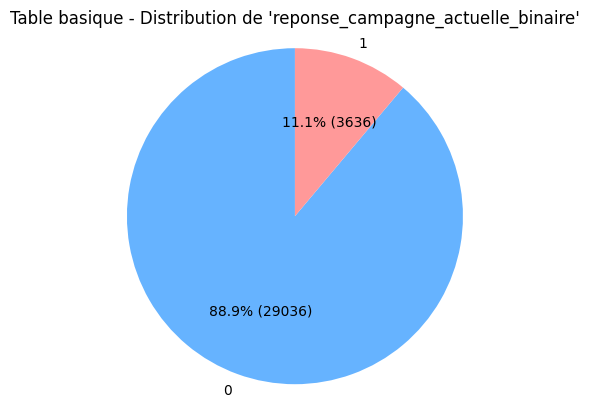

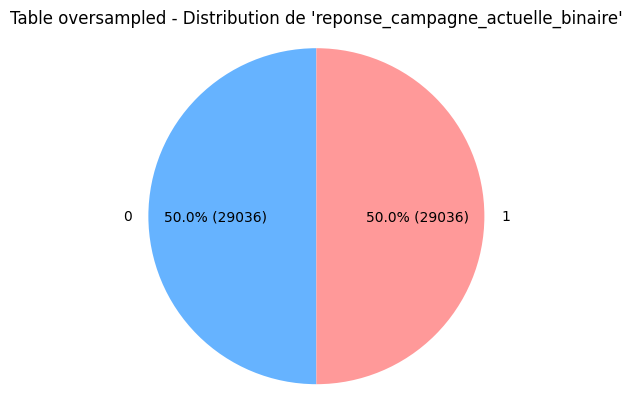

In [75]:
# Fonction pour créer un pie chart avec les proportions et les nombres
def plot_pie_chart(y, title):
    labels = ['0', '1']
    sizes = y.value_counts().values
    colors = ['#66b3ff', '#ff9999']

    # Modifier le format des labels pour inclure les proportions et les nombres
    def autopct_format(pct, all_values):
        absolute = int(round(pct / 100 * sum(all_values)))
        return f"{pct:.1f}% ({absolute})"

    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, colors=colors, autopct=lambda pct: autopct_format(pct, sizes), startangle=90)
    ax.axis('equal')  # Pour assurer que le diagramme est bien rond
    plt.title(title)
    plt.show()

# Créer un pie chart pour la table basique
plot_pie_chart(y_train, "Table basique - Distribution de 'reponse_campagne_actuelle_binaire'")

# Créer un pie chart pour la table oversampled
plot_pie_chart(y_train_oversampled, "Table oversampled - Distribution de 'reponse_campagne_actuelle_binaire'")


## Impact sur le modèle

In [76]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# Entraîner et évaluer la régression logistique sur la base basique
logreg_basique = sm.Logit(y_train, X_train).fit()
y_pred_basique = logreg_basique.predict(X_test)
y_pred_basique_train = logreg_basique.predict(X_train)
auc_basique = roc_auc_score(y_test, y_pred_basique)
auc_train_basique = roc_auc_score(y_train, y_pred_basique_train)
# Entraîner et évaluer la régression logistique sur la base oversampled
logreg_oversampled = sm.Logit(y_train_oversampled, X_train_oversampled).fit(disp=0)
y_pred_oversampled = logreg_oversampled.predict(X_test)
auc_oversampled = roc_auc_score(y_test, y_pred_oversampled)
y_pred_oversampled_train = logreg_oversampled.predict(X_train_oversampled)
auc_oversampled_train = roc_auc_score(y_train_oversampled, y_pred_oversampled_train)


Optimization terminated successfully.
         Current function value: 0.234362
         Iterations 8


In [77]:
# Créer un DataFrame avec les performances
performances = pd.DataFrame({
    'Modèle': ['Base basique', 'Base oversampled'],
    'AUC - Entraînement': [auc_train_basique, auc_oversampled_train],
    'AUC - Test': [auc_basique, auc_oversampled]
})

# Afficher les performances
print(performances)

             Modèle  AUC - Entraînement  AUC - Test
0      Base basique            0.907056    0.912754
1  Base oversampled            0.907918    0.914676


## Undersampling ou sous échantillonage

L'undersampling est une technique de rééchantillonnage utilisée pour gérer les ensembles de données déséquilibrés en réduisant le nombre d'échantillons de la classe majoritaire. Cela peut être fait en supprimant aléatoirement des échantillons de la classe majoritaire ou en utilisant des méthodes plus sophistiquées telles que Tomek Links ou ENN (Edited Nearest Neighbors).

### Avantages

Réduit la taille de l'ensemble de données, ce qui peut diminuer les temps d'apprentissage et de prédiction.

Peut améliorer la performance du modèle sur la classe minoritaire en réduisant le biais envers la classe majoritaire.

Élimine les échantillons bruyants ou redondants de la classe majoritaire, ce qui peut simplifier le modèle et éviter le surapprentissage.

### Inconvénients

Peut entraîner une perte d'informations importantes en supprimant des échantillons de la classe majoritaire, ce qui peut nuire à la performance globale du modèle.

Ne résout pas toujours le problème du déséquilibre des classes ; dans certains cas, l'oversampling ou d'autres techniques de rééchantillonnage peuvent être plus appropriées.

Peut ne pas être efficace si la classe majoritaire contient de nombreuses sous-classes ou groupes distincts, car l'undersampling peut éliminer certains de ces groupes et réduire la capacité du modèle à les distinguer.

### Analyse

In [78]:
# Importer les bibliothèques nécessaires
from imblearn.under_sampling import RandomUnderSampler

# Initialiser l'objet RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Appliquer l'undersampling sur les données d'apprentissage
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)

# Créer un nouveau DataFrame avec les données undersampled
bankdata_undersampled = pd.concat([X_train_undersampled, y_train_undersampled], axis=1)

# Afficher la nouvelle distribution des données
print(bankdata_undersampled['reponse_campagne_actuelle_binaire'].value_counts())

reponse_campagne_actuelle_binaire
0    3636
1    3636
Name: count, dtype: int64


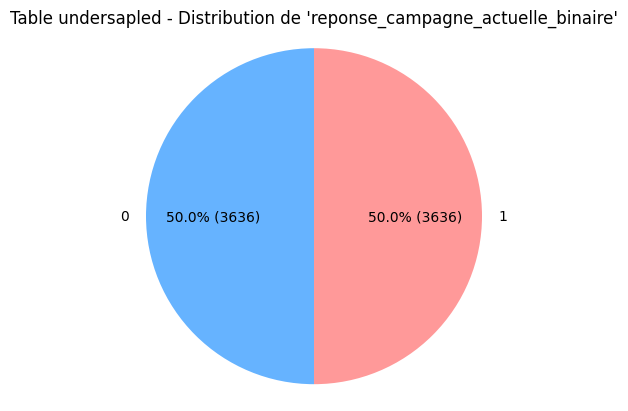

In [79]:
# Créer un pie chart pour la table oversampled
plot_pie_chart(y_train_undersampled, "Table undersapled - Distribution de 'reponse_campagne_actuelle_binaire'")


### Impact sur le modèle

In [80]:
# Entraîner et évaluer la régression logistique sur la base undersampled

# Entraîner et évaluer la régression logistique sur la base oversampled
lr_undersampled = sm.Logit(y_train_undersampled, X_train_undersampled).fit()


y_pred_undersampled = lr_undersampled.predict(X_test)
auc_undersampled = roc_auc_score(y_test, y_pred_undersampled)

# Ajouter les performances de la base undersampled au DataFrame
performances.loc[2] = ['Base undersampled', auc_undersampled, auc_undersampled]

# Afficher les performances
print(performances)

Optimization terminated successfully.
         Current function value: 0.393475
         Iterations 7
              Modèle  AUC - Entraînement  AUC - Test
0       Base basique            0.907056    0.912754
1   Base oversampled            0.907918    0.914676
2  Base undersampled            0.914297    0.914297


###

## Rééchantillonage SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE est une technique de rééchantillonnage spécifique pour gérer les ensembles de données déséquilibrés.

SMOTE génère des échantillons synthétiques de la classe minoritaire en utilisant l'interpolation entre les échantillons existants. Pour chaque échantillon de la classe minoritaire, SMOTE sélectionne un certain nombre de ses voisins les plus proches appartenant à la même classe, puis génère de nouveaux échantillons en interpolant les attributs de l'échantillon original et de ses voisins.

### Avantages

Améliore la performance du modèle sur la classe minoritaire en augmentant la quantité d'informations disponibles pour l'apprentissage.

Réduit le biais envers la classe majoritaire, ce qui peut améliorer la précision globale du modèle.

Génère des échantillons synthétiques plutôt que de dupliquer les échantillons existants, ce qui peut aider à éviter le surapprentissage et permettre une meilleure généralisation.

### Inconvénients

Peut créer des échantillons synthétiques qui ne représentent pas la réalité, ce qui peut entraîner un modèle moins robuste ou moins généralisable.

Augmente la taille de l'ensemble de données, ce qui peut augmenter les temps d'apprentissage et de prédiction.

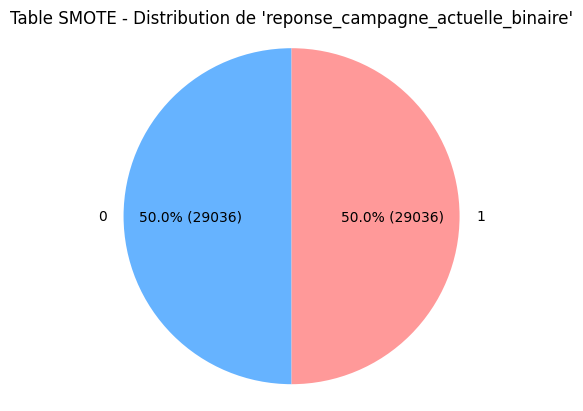

In [81]:
## Rééchantillonge SMOTE sur la base d'apprentissage
from imblearn.over_sampling import SMOTE

# Initialiser l'objet SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Appliquer le rééchantillonnage SMOTE sur les données d'apprentissage
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Créer un nouveau DataFrame avec les données rééchantillonnées
bankdata_smote = pd.concat([X_train_smote, y_train_smote], axis=1)

# Afficher la nouvelle distribution des données

plot_pie_chart(y_train_smote, "Table SMOTE - Distribution de 'reponse_campagne_actuelle_binaire'")


In [82]:
# Entraîner et évaluer la régression logistique sur la base SMOTE




lr_smote = sm.Logit(y_train_smote, X_train_smote).fit()
y_pred_smote = lr_smote.predict(X_test)
auc_smote = roc_auc_score(y_test, y_pred_smote)

# Ajouter les performances de la base SMOTE au DataFrame
performances.loc[3] = ['Base SMOTE', auc_smote, auc_smote]

# Afficher les performances
print(performances)


Optimization terminated successfully.
         Current function value: 0.188768
         Iterations 8
              Modèle  AUC - Entraînement  AUC - Test
0       Base basique            0.907056    0.912754
1   Base oversampled            0.907918    0.914676
2  Base undersampled            0.914297    0.914297
3         Base SMOTE            0.872724    0.872724


### Analyse

**Base oversampled (meilleur choix)**

Meilleure AUC Test (0.915)

Très bonne généralisation (train ≈ test)

Modèle le plus performant globalement

**Base undersampled**

Bonne performance (0.914)

Stable (pas de surapprentissage)

Bon compromis mais perte possible d’information (car on réduit les données)

**Base basique**

Déjà très bon (0.913)

Le déséquilibre ne pénalisait pas énormément ton modèle au départ

**Base SMOTE**

Performance plus faible (0.873)

Moins efficace ici (peut introduire du bruit)

**Conclusion**

Le meilleur modèle est : oversampled

Le modèle undersampled est aussi très solide

SMOTE n’apporte pas d’amélioration dans ton cas

**Lecture importante (niveau expert)**

Tous les modèles ont Train ≈ Test
Pas de surapprentissage

Les gains sont faibles
Ton modèle de base était déjà bon

## ADASYN (Adaptive Synthetic Sampling)

ADASYN est une technique de rééchantillonnage pour gérer les ensembles de données déséquilibrés.

ADASYN est similaire à SMOTE, mais génère des échantillons synthétiques en adaptant la densité des échantillons minoritaires selon leurs voisins. ADASYN accorde plus d'importance aux échantillons de la classe minoritaire qui sont difficiles à apprendre, en créant plus d'échantillons synthétiques pour ces échantillons.

### Avantages

Améliore la performance du modèle sur la classe minoritaire en augmentant la quantité d'informations disponibles pour l'apprentissage.

Réduit le biais envers la classe majoritaire, ce qui peut améliorer la précision globale du modèle.

Génère des échantillons synthétiques adaptés aux régions où la classe minoritaire est difficile à apprendre, ce qui peut aider à éviter le surapprentissage et permettre une meilleure généralisation.

Peut être combiné avec d'autres techniques de rééchantillonnage, telles que l'undersampling, pour créer un ensemble de données équilibré.

### Inconvénients

Peut créer des échantillons synthétiques qui ne représentent pas la réalité, ce qui peut entraîner un modèle moins robuste ou moins généralisable.

Augmente la taille de l'ensemble de données, ce qui peut augmenter les temps d'apprentissage et de prédiction.

### Implémentation

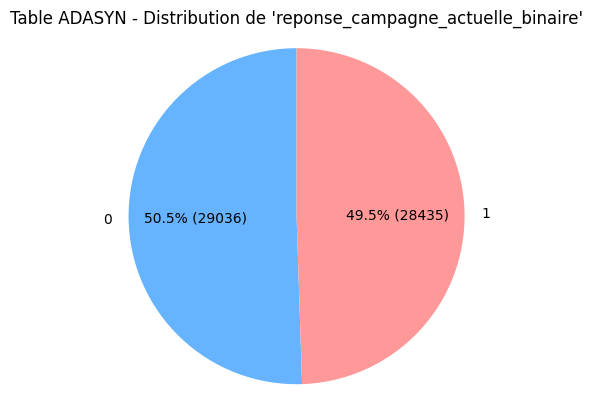

In [84]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy='auto', random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)



# Créer un pie chart pour la table oversampled
plot_pie_chart(y_train_adasyn, "Table ADASYN - Distribution de 'reponse_campagne_actuelle_binaire'")

In [85]:
# Fonction pour l'oversampling stratifié basé sur une colonne spécifique
def stratified_oversampling(data, target_col, stratify_col):
    unique_strata = data[stratify_col].unique()
    oversampled_data = pd.DataFrame(columns=data.columns)

    for stratum in unique_strata:
        stratum_data = data[data[stratify_col] == stratum]
        X = stratum_data.drop(target_col, axis=1)
        y = stratum_data[target_col]

        ros = RandomOverSampler(random_state=42)
        X_resampled, y_resampled = ros.fit_resample(X, y)

        resampled_data = pd.concat([X_resampled, y_resampled], axis=1)
        oversampled_data = pd.concat([oversampled_data, resampled_data])

    return oversampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Application de l'oversampling stratifié
oversampled_bankdata = stratified_oversampling(bankdata, 'reponse_campagne_actuelle_binaire', 'niveau_etudes')

# Affichage des proportions de niveaux d'études avant et après l'oversampling stratifié
print("Proportions avant l'oversampling stratifié :")
print(bankdata['niveau_etudes'].value_counts(normalize=True))

print("\nProportions après l'oversampling stratifié :")
print(oversampled_bankdata['niveau_etudes'].value_counts(normalize=True))


/tmp/ipykernel_7099/3908988561.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  oversampled_data = pd.concat([oversampled_data, resampled_data])


Proportions avant l'oversampling stratifié :
niveau_etudes
secondary    0.537034
tertiary     0.303127
primary      0.159839
Name: proportion, dtype: float64

Proportions après l'oversampling stratifié :
niveau_etudes
secondary    0.542898
tertiary     0.291890
primary      0.165212
Name: proportion, dtype: float64
